In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rv_continuous

In [2]:
PDF_X = np.linspace(0, 200, 1000)
trapezoid = np.trapz

In [3]:
class AsymmetricGaussian(rv_continuous):
    """
    Custom Asymmetric Gaussian distribution.
    Use loc for the mean, and unc_minus/unc_plus as shape parameters.
    """
    def _pdf(self, x, unc_minus, unc_plus):
        """x is already shifted by loc internally by scipy"""
        pdf = np.where(
            x < 0,
            np.exp(-0.5 * (x / unc_minus)**2),
            np.exp(-0.5 * (x / unc_plus)**2)
        )
        
        norm = np.sqrt(2 / (np.pi * (unc_plus + unc_minus)**2))
        return norm * pdf

    def _rvs(self, unc_minus, unc_plus, size=None, random_state=None):
        """Generate random samples from the asymmetric Gaussian"""
        rng = np.random.default_rng()
        # To match _pdf, each side must carry mass unc/(unc_minus + unc_plus),
        # not 50/50: pick the side first, then draw a half-normal on that side
        left = rng.random(size) < unc_minus / (unc_minus + unc_plus)
        half = np.abs(rng.standard_normal(size))
        samples = np.where(left, -half * unc_minus, half * unc_plus)
        return samples

ag = AsymmetricGaussian()

In [4]:
base_loc = 100
base_std = 5
base_pdf = ag.pdf(PDF_X, loc=base_loc, unc_minus=base_std, unc_plus=base_std)

test_pdfs = dict(
    base_pdf = dict(loc=100,unc_minus=5, unc_plus=5),
    deltafunc_pdf = dict(loc=100, unc_minus=1, unc_plus=1),
    deltafunc_slightly_offset_pdf = dict(loc=105, unc_minus=1, unc_plus=1),
    deltafunc_offset_pdf = dict(loc=150, unc_minus=1, unc_plus=1),
    wide_pdf = dict(loc=100,unc_minus=10, unc_plus=10),
    wide_slightly_offset_pdf = dict(loc=105, unc_minus=10, unc_plus=10),
    wide_pdf_offset = dict(loc=115, unc_minus=10, unc_plus=10),
    wide_pdf_veryoffset = dict(loc=150,unc_minus=10, unc_plus=10),
    verywide_pdf = dict(loc=100,unc_minus=50, unc_plus=50),
    verywide_slightly_offset_pdf = dict(loc=105,unc_minus=50, unc_plus=50),
    verywide_pdf_offset = dict(loc=150,unc_minus=50, unc_plus=50),
    asymmetric_pdf_deltafunc = dict(loc=100, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_deltafunc_offset = dict(loc=150, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_wide = dict(loc=100, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset = dict(loc=150, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset_neg = dict(loc=50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_very_skewed = dict(loc=100, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_offset = dict(loc=120, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_pos = dict(loc=180, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_neg = dict(loc=(100-80), unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_slightly_offset_neg = dict(loc=95, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_moderately_offset_neg = dict(loc=92, unc_minus=50, unc_plus=1),
    # Straddles the GW: mode below (-6) with a narrow lower tail (unc_minus=1)
    # facing the GW and a wide upper tail (unc_plus=15) pointing away. The median
    # lands just above the GW, so v4 scores it on the narrow facing tail ALONE
    # and ignores the large far-side uncertainty; v2 blends both tails in. This
    # is the structure that maximizes the v2-vs-v4 disagreement.
    asymmetric_v4_straddle = dict(loc=94, unc_minus=1, unc_plus=15),
)

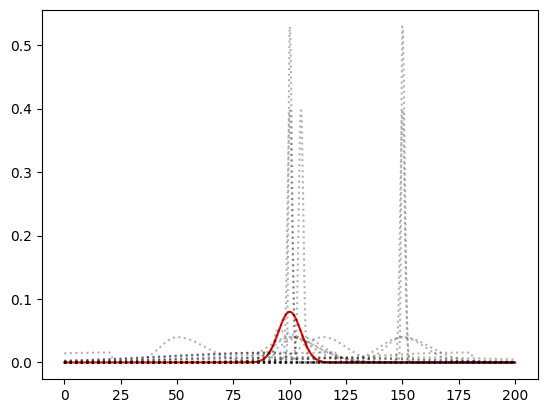

In [5]:
fig, ax = plt.subplots()

ax.plot(PDF_X, base_pdf, color="r")

for label, test_params in test_pdfs.items():
    test = ag.pdf(PDF_X, **test_params)
    ax.plot(PDF_X, test, color="k", alpha=0.3, linestyle=":")

In [14]:
from scipy.special import erf, erfc

# TODO: New stuff to mess around with
def normalization_prefactor(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos):
    prefactor_cand = np.sqrt(2/np.pi) * (sigma_cand_pos + sigma_cand_neg*erf(mean_cand/(sigma_cand_neg*np.sqrt(2))))**-1
    prefactor_gw = float(sigma_gw)**-1 * np.sqrt(2/np.pi) * (1 + erf(mean_gw/(sigma_gw*np.sqrt(2))))**-1
    print(prefactor_cand)
    print(prefactor_gw)
    return np.sqrt(prefactor_cand*prefactor_gw)

def a(sigma_gw, sigma_cand):
    return 1/sigma_gw**2 + 1/sigma_cand**2
        
def b(mean_gw, sigma_gw, mean_cand, sigma_cand):
    return mean_gw/sigma_gw**2 + mean_cand/sigma_cand**2

def c(mean_gw, sigma_gw, mean_cand, sigma_cand):
    return (mean_gw/sigma_gw)**2 + (mean_cand/sigma_cand)**2

def p(_a, _b, _c):
    return np.sqrt(np.pi/_a) * np.exp(-0.25*(_c - _b**2/_a))

def bc_integral_neg(mean_gw, sigma_gw, mean_cand, sigma_cand_neg):
    _a = a(sigma_gw, sigma_cand_neg)
    _b = b(mean_gw, sigma_gw, mean_cand, sigma_cand_neg)
    _c = c(mean_gw, sigma_gw, mean_cand, sigma_cand_neg)

    _p = p(_a, _b, _c)
    x0 = erf(-_b/(2*np.sqrt(_a)))
    x1 = erf(np.sqrt(_a)/2 * (mean_cand - _b/_a))
    return _p*(x1-x0)

def bc_integral_pos(mean_gw, sigma_gw, mean_cand, sigma_cand_pos):
    _a = a(sigma_gw, sigma_cand_pos)
    _b = b(mean_gw, sigma_gw, mean_cand, sigma_cand_pos)
    _c = c(mean_gw, sigma_gw, mean_cand, sigma_cand_pos)

    _p = p(_a, _b, _c)
    return _p*erfc(np.sqrt(_a)/2 * (mean_cand - _b/_a))

def bc(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos):
    lower_args = (mean_gw, sigma_gw, mean_cand, sigma_cand_neg)
    upper_args = (mean_gw, sigma_gw, mean_cand, sigma_cand_pos)
    norm = normalization_prefactor(mean_gw, sigma_gw, mean_cand, sigma_cand_neg, sigma_cand_pos)
    return norm*(bc_integral_neg(*lower_args) + bc_integral_pos(*upper_args))

# TODO: What is the impact of this k parameter in the distance scoring? 
def sigmoid(x, k=1):
    return 1 / (1 + np.exp(-k * x))

def smooth_tophat(x, a, b, k=1):
    return sigmoid(x - a, k) * (1 - sigmoid(x - b, k))

def smooth_tophat_score(galaxy_dist, gw_mean, gw_std, nsigma=2):
    return smooth_tophat(galaxy_dist, gw_mean-nsigma*gw_std, gw_mean+nsigma*gw_std)


def hybrid(gw_mean, galaxy_mean, gw_std, galaxy_std_minus, galaxy_std_plus):

    if galaxy_std_minus == 0 or galaxy_std_plus == 0:
        bc_score = 0 # this score should be computed in the sigmoid regime
    else:
        bc_score = bc(gw_mean, gw_std, galaxy_mean, galaxy_std_minus, galaxy_std_plus)

    tophat_score = smooth_tophat_score(galaxy_mean, gw_mean, gw_std)

    # What is the reason why this specifically and not gw_std**2 or something non-linear with the uncertainties?
    # this weight will be small for spec-z's and large for photo-z's   
    w = np.mean([galaxy_std_minus, galaxy_std_plus], axis=0) / gw_std
    max_w = np.ones(w.shape)
    w = np.min([max_w, w], axis=0)

    print(f"\tBC={bc_score}", f"S={tophat_score}", f"w={w}", f"score={(1-w)*tophat_score + w*bc_score}")

    return np.clip((1-w)*tophat_score + w*bc_score, 0, 1)


In [15]:
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)

    final_score = hybrid(base_loc, test['loc'], base_std, test['unc_minus'], test['unc_plus'])

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"hybrid_new/v1/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

0.07978845608028655
0.07978845608028655
	BC=1.0000000000000002 S=0.9999092063235617 w=1.0 score=1.0000000000000002
0.3989422804014327
0.07978845608028655
	BC=0.6201736729460423 S=0.9999092063235617 w=0.2 score=0.9239620996480579
0.3989422804014327
0.07978845608028655
	BC=0.48765829288336193 S=0.9933068452208461 w=0.2 score=0.8921771347533494
0.3989422804014327
0.07978845608028655
	BC=2.252901096617221e-11 S=0.0 w=0.2 score=4.505802193234442e-12
0.039894228040143274
0.07978845608028655
	BC=0.894427190999916 S=0.9999092063235617 w=1.0 score=0.894427190999916
0.039894228040143274
0.07978845608028655
	BC=0.8508054621526306 S=0.9933068452208461 w=1.0 score=0.8508054621526306
0.039894228040143274
0.07978845608028655
	BC=0.5703119565575377 S=0.006692850924191782 w=1.0 score=0.5703119565575377
0.039894228040143274
0.07978845608028655
	BC=0.006026603007498328 S=0.0 w=1.0 score=0.006026603007498328
0.008164591133621477
0.07978845608028655
	BC=0.4501440362040477 S=0.9999092063235617 w=1.0 score=0